In [24]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from keras.utils import to_categorical 
from keras.models import Sequential 
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
import cv2
np.random.seed(42)
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [25]:
#--------------------------------------------------#
# Loading the dataset
#--------------------------------------------------#

data = []
labels = []

data_path = "/workspaces/Elevvo_Internship_Tasks/Task4_Traffic sign recognition/GTSRB---German-Traffic-Sign-Recognition-main/gtsrb-german-traffic-sign/Train"

# Automatically detect classes from folder names
class_folders = [f for f in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, f))]
classes = len(class_folders)
print(f"Detected: {classes} classes")

for folder in class_folders:
    folder_path = os.path.join(data_path, folder)
    images = os.listdir(folder_path)
    for img_name in images:
        try:
            img_path = os.path.join(folder_path, img_name)
            image = Image.open(img_path).convert("RGB")
            image = image.resize((30, 30))
            image = np.array(image)
            data.append(image)
            labels.append(int(folder))  # use folder name as label
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")

data = np.array(data)
labels = np.array(labels)

print("Dataset:", data.shape, "Labels:", labels.shape)

Detected: 43 classes
Dataset: (39209, 30, 30, 3) Labels: (39209,)


In [26]:
#--------------------------------------------#
#Splitting training and testing dataset
#--------------------------------------------#

x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize the image data
x_train = x_train/255.0
x_test = x_test/255.0

#Converting the labels into one hot encoding

num_classes = len(np.unique(labels))
y_train = to_categorical(y_train, len(np.unique(y_train)))
y_test = to_categorical(y_test, len(np.unique(y_test)))
print(y_test.shape)
print(x_test.shape)

(7842, 43)
(7842, 30, 30, 3)


In [27]:
print(y_test.shape, x_test.shape )

(7842, 43) (7842, 30, 30, 3)


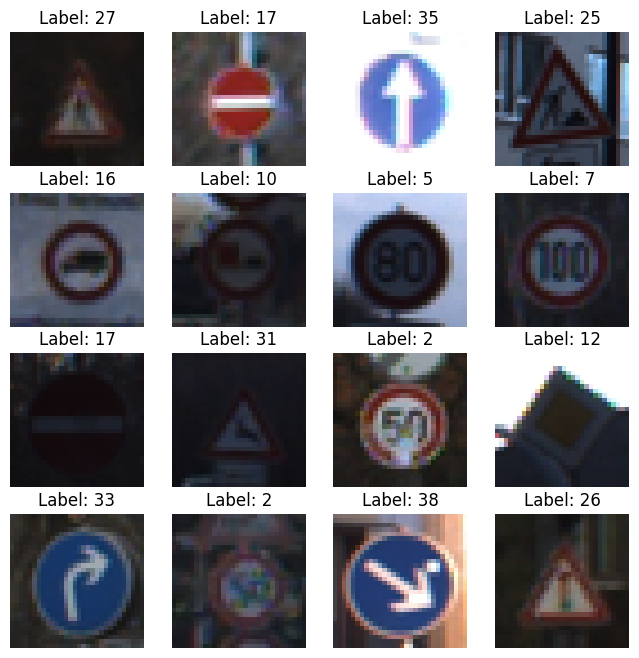

In [28]:
#---------------------------------------------------#
# Visualizing images within our training dataset
#---------------------------------------------------#
num_images = 16

plt.figure(figsize=(8, 8))
for i in range(num_images):
    plt.subplot(4, 4, i+1)  # 3x3 grid
    plt.imshow(x_train[i])   # X_train images are already numpy arrays
    plt.title(f"Label: {np.argmax(y_train[i])}")  # Show label (one-hot back to index)
    plt.axis('off')          # Hide axes
plt.show()


In [29]:
#-----------------------------------------#
#Data Augmentation
#-----------------------------------------#


datagen = ImageDataGenerator(
    rotation_range=15,         # rotate images ±15 degrees
    zoom_range=0.2,            # random zoom
    width_shift_range=0.2,     # horizontal shift
    height_shift_range=0.2,    # vertical shift
    shear_range=0.15,          # shear transformation
    brightness_range=[0.7, 1.3],  # random brightness
    horizontal_flip=False,     # traffic signs usually not flipped
    fill_mode='nearest'        # fill pixels after transformations
)
datagen.fit(x_train)

In [30]:
#-----------------------------------------------#
#BUILDING OUR CNN MODEL
#-----------------------------------------------#

model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same', input_shape=x_train.shape[1:]))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Classification head
model.add(GlobalAveragePooling2D())  # reduces parameters, helps generalization
model.add(Dense(256, activation='relu', kernel_initializer='he_normal'))
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))

# Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 332,875 (1.27 MB)

 Trainable params: 331,979 (1.27 MB)

 Non-trainable params: 896 (3.50 KB)

In [31]:
#---------------------------------------------#
# COMPILATION OF THE MODEL 
#---------------------------------------------#


# Use a learning rate schedule for better convergence
optimizer = Adam(learning_rate=0.001)  # can adjust later or use a scheduler

model.compile(
    loss='categorical_crossentropy',   # multi-class classification
    optimizer=optimizer,
    metrics=['accuracy']
)

In [32]:
#--------------------------------#
# MODEL TRAINING
#---------------------------------#

eps = 30
history = model.fit(x_train, y_train, batch_size=32, epochs=eps, validation_data=(x_test, y_test))

Epoch 1/30


2025-09-03 15:16:35.628736: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 338763600 exceeds 10% of free system memory.


981/981 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.5150 - loss: 1.6948 - val_accuracy: 0.8994 - val_loss: 0.2917
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 72s 73ms/step - accuracy: 0.9221 - loss: 0.2514 - val_accuracy: 0.9823 - val_loss: 0.0591
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 71s 73ms/step - accuracy: 0.9713 - loss: 0.0978 - val_accuracy: 0.9871 - val_loss: 0.0370
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - accuracy: 0.9795 - loss: 0.0684 - val_accuracy: 0.9915 - val_loss: 0.0272
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 71s 73ms/step - accuracy: 0.9837 - loss: 0.0553 - val_accuracy: 0.9960 - val_loss: 0.0120
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 72s 74ms/step - accuracy: 0.9875 - loss: 0.0409 - val_accuracy: 0.9948 - val_loss: 0.0193
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 72s 73ms/step - accuracy: 0.9882 - loss: 0.0392 - val_accuracy: 0.9945 - val_loss: 0.0174
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.9897 - loss: 0.0350 - val_accurac

In [33]:
#SAVE MODEL
model.save("traffic_classifier1.h5")

In [37]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(f"Validation Accuracy: {val_acc:.2f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9980 - loss: 0.0089
Validation Accuracy: 1.00


In [ ]:
#----------------------------------------#
#EVALUATING THE MODEL FROM TEST DATASET
#----------------------------------------#

# Importing the test dataset
y_test = pd.read_csv('/workspaces/Elevvo_Internship_Tasks/Task4_Traffic sign recognition/GTSRB---German-Traffic-Sign-Recognition-main/gtsrb-german-traffic-sign/Test.csv')

labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data=[]

# Retreiving the images
with tf.device('/GPU:0'):
    for img in imgs:
        image = Image.open('/workspaces/Elevvo_Internship_Tasks/Task4_Traffic sign recognition/GTSRB---German-Traffic-Sign-Recognition-main/gtsrb-german-traffic-sign/'+img)
        image = image.resize([30, 30])
        data.append(np.array(image))

x_test=np.array(data)
pred = np.argmax(model.predict(x_test), axis=-1)

#Accuracy with the test data
from sklearn.metrics import accuracy_score
print(accuracy_score(labels, pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
0.8699920823436262


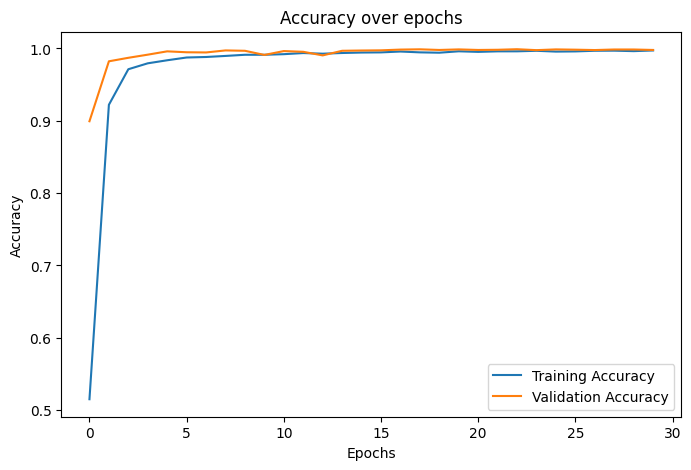

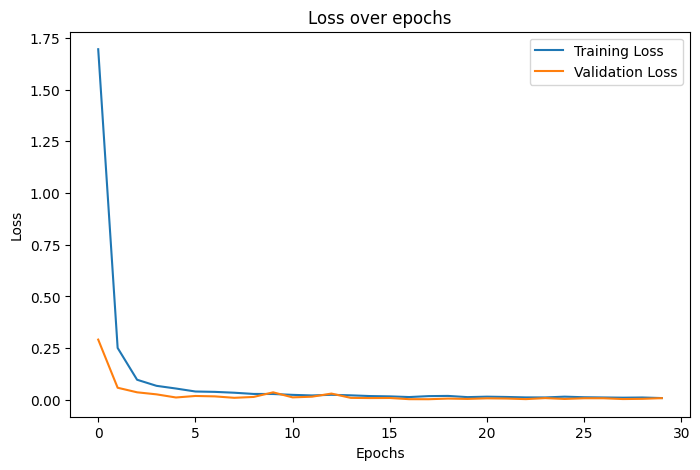

In [39]:
#--------------------------------------------#

#PLOTTING TRAINING AND VALIDATION ACCURACY
#--------------------------------------------#

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

  1/395 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step

395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step


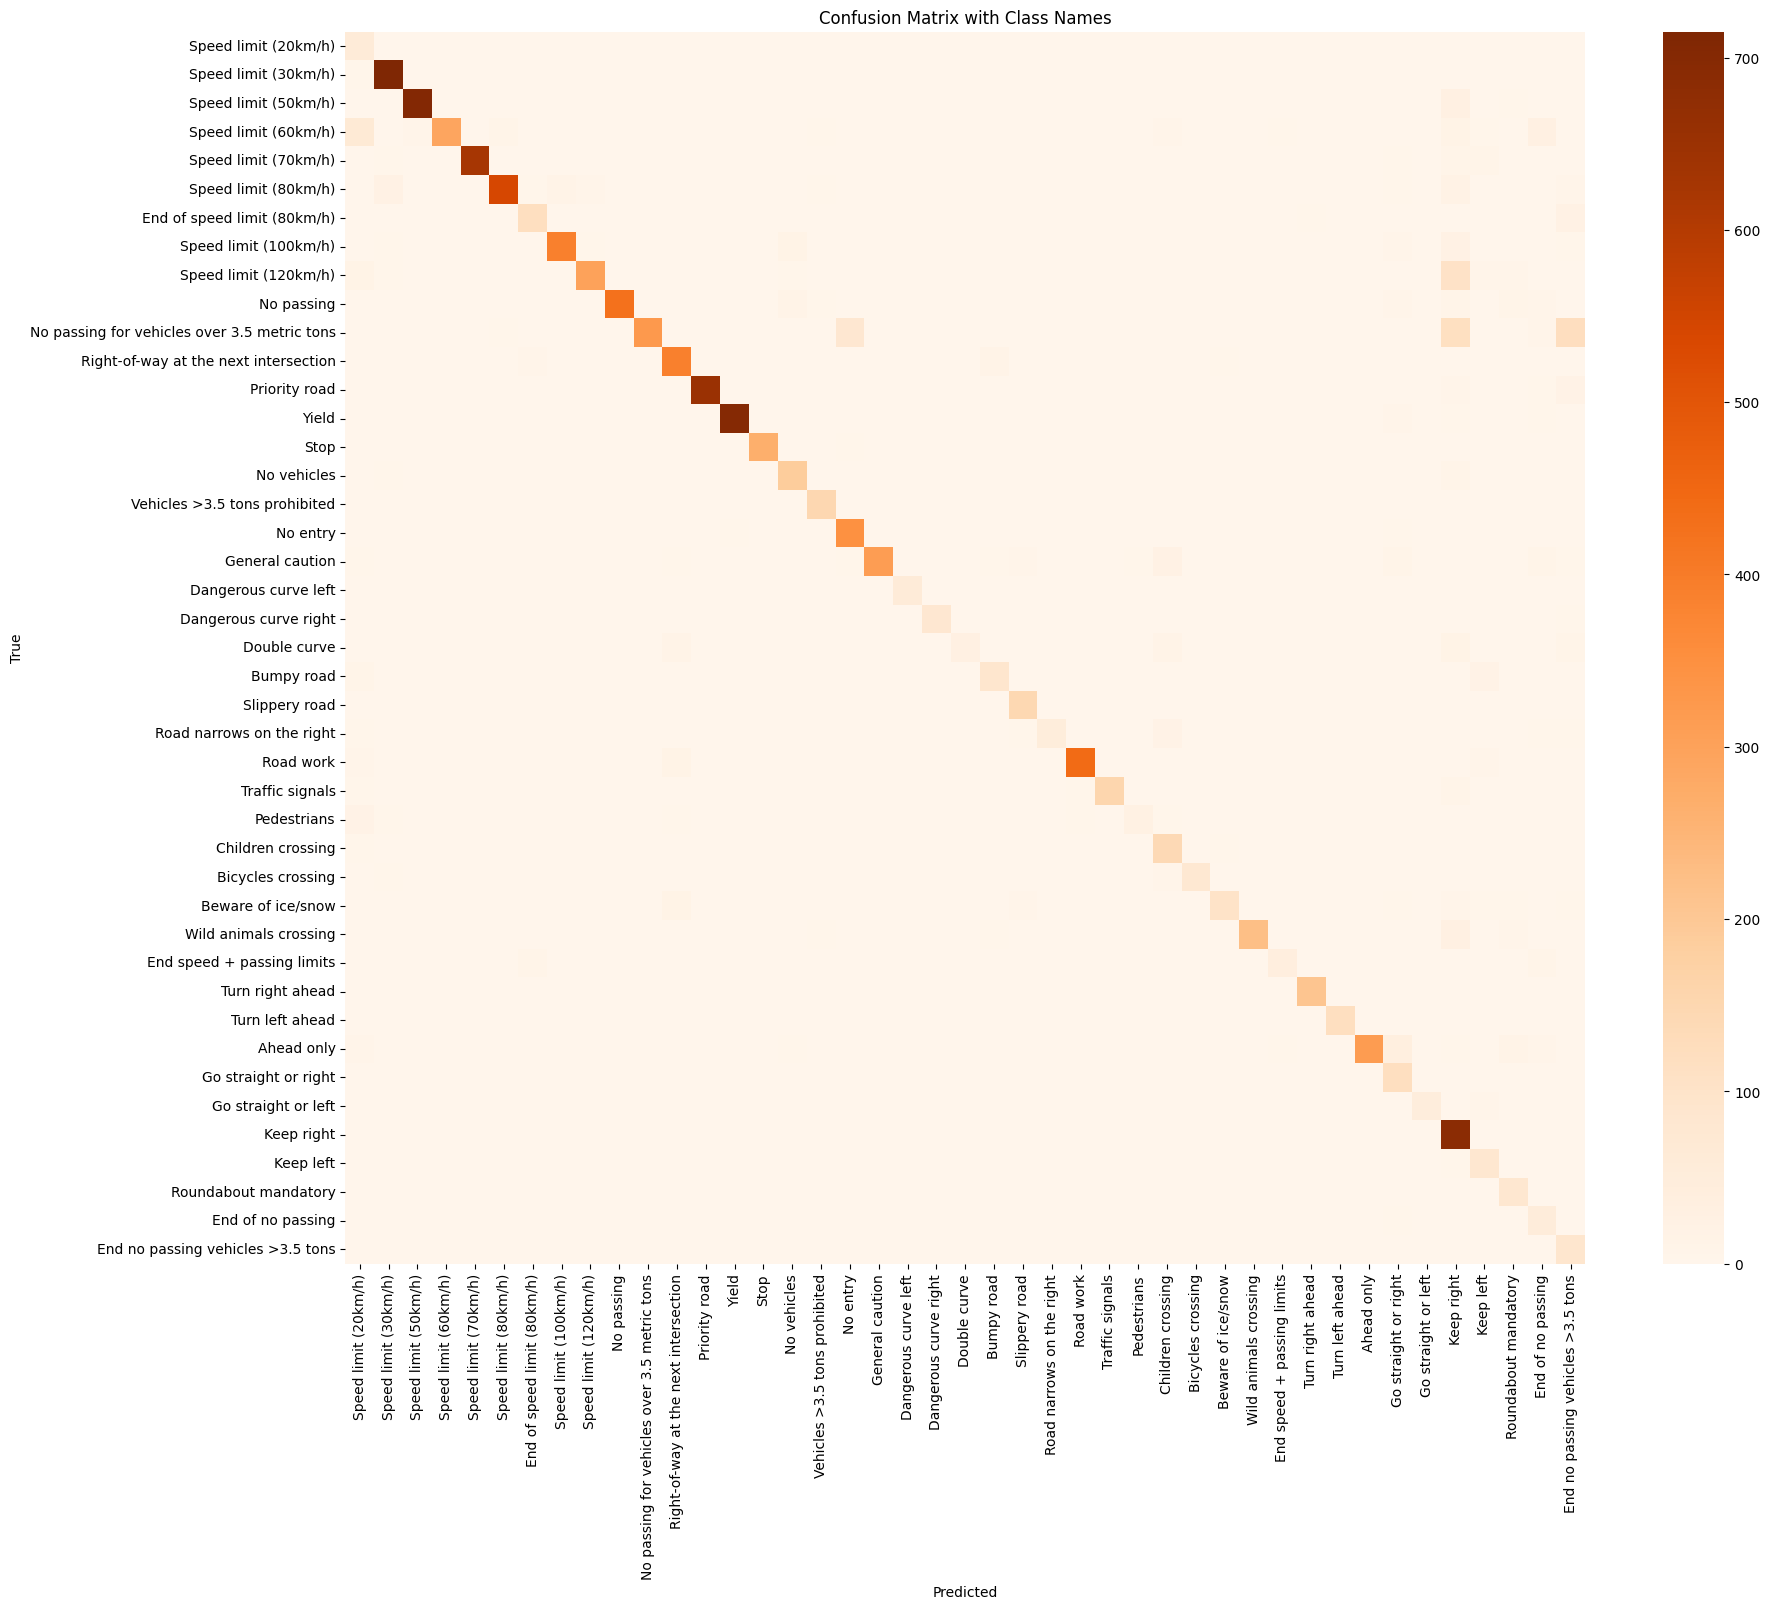

In [ ]:
#----------------------------------------#
# PLOTTING CONFUSION MATRIX
#----------------------------------------#


# ✅ Define GTSRB class names (43 classes)
class_names = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
    "Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
    "End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
    "No passing", "No passing for vehicles over 3.5 metric tons",
    "Right-of-way at the next intersection", "Priority road", "Yield", "Stop",
    "No vehicles", "Vehicles >3.5 tons prohibited", "No entry",
    "General caution", "Dangerous curve left", "Dangerous curve right",
    "Double curve", "Bumpy road", "Slippery road", "Road narrows on the right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing",
    "Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
    "End speed + passing limits", "Turn right ahead", "Turn left ahead",
    "Ahead only", "Go straight or right", "Go straight or left", "Keep right",
    "Keep left", "Roundabout mandatory", "End of no passing",
    "End no passing vehicles >3.5 tons"
]

# ✅ Predictions

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ✅ Use labels directly (already integers)
y_true = labels  # or y_test if it's integers already

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap="Oranges", fmt="d",
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix with Class Names")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()
